In [1]:
import matplotlib.pyplot as plt
from FastBEMT import BEMT, Environment, Propeller, Simulation
from FastBEMT.Utils.DataLoader import load_propeller_dict
import scienceplots
plt.style.use(['science', 'no-latex'])

In [2]:
prop_name, blade_dict = load_propeller_dict('Data/10x7E')[0]

environment = Environment(
    a_inf=343,
    rho=1.225,
    mu=1.81e-5,
    p_ref=2e-5,
)
simulation = Simulation(
    revolutions=1,
    timesteps_per_revolution=100,
    device='cpu',
)

propeller = Propeller(
    geometry=blade_dict,
    environment=environment,
    simulation=simulation,
)

bemt = BEMT(
    propeller=propeller,
    environment=environment,
    rpm=[3000, 7000],
    J=[0.0, 0.5],
)
performance = bemt.performance

print(f'Propeller: {prop_name}')
performance

c:\Users\PusinoDavide\FastBEMT\.venv\Lib\site-packages\neuralfoil\main.py:171: RuntimeWarning: divide by zero encountered in log
  (np.log(Re) - 12.5) / 3.5,
c:\Users\PusinoDavide\FastBEMT\.venv\Lib\site-packages\aerosandbox\numpy\surrogate_model_tools.py:253: RuntimeWarning: invalid value encountered in divide
  return x / (1 + _np.exp(-beta * x))
c:\Users\PusinoDavide\FastBEMT\.venv\Lib\site-packages\neuralfoil\main.py:227: RuntimeWarning: invalid value encountered in matmul
  x = w @ x + np.reshape(b, (-1, 1))
c:\Users\PusinoDavide\FastBEMT\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
c:\Users\PusinoDavide\FastBEMT\.venv\Lib\site-packages\aerosandbox\library\aerodynamics\viscous.py:142: RuntimeWarning: divide by zero encountered in scalar divide
  return 0.074 / Re_L ** (1 / 5)
C:\Users\PusinoDavide\FastBEMT\src\FastBEMT\Aerodynamics\Section.py:156: RuntimeWarning

Propeller: 10x7E


thrust    torque  thrust_coefficient  torque_coefficient  \
rpm    v_inf                                                                   
3000.0 0.000000   1.136030  0.026098            0.089121            0.008060   
       6.350000   0.526047  0.018600            0.041268            0.005745   
7000.0 0.000000   7.980068  0.139295            0.114985            0.007902   
       14.816667  4.600537  0.133019            0.066289            0.007546   

                  figure_of_merit  
rpm    v_inf                       
3000.0 0.000000          0.419154  
       6.350000          0.185316  
7000.0 0.000000          0.626592  
       14.816667         0.287217

In [3]:
sol = bemt.solution_for(rpm=7000, v_inf=0.0)
sol.head()

,r,dr,chord,twist,phi,alpha,Cl,Cd,u,a_prime,d_t,d_q,F,W,Re,Ma,ds,dp
section,,,,,,,,,,,,,,,,,,
0,0.000000,0.001397,0.020320,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.002794,0.002794,0.019367,1.2466,45.000000,-43.753400,-1.634310,0.050220,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN
2,0.005588,0.002794,0.018303,4.9140,45.000000,-40.086000,-0.640083,-0.206385,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,0.001340,0.008954
3,0.008382,0.002794,0.017356,10.8533,45.000000,-34.146700,-0.650976,-0.219735,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,0.001130,0.008525
4,0.011176,0.002794,0.016774,18.5902,9.505202,9.084998,0.138957,0.175926,1.131562,0.17487,0.000375,0.000005,0.608753,6.853879,7780.987754,0.019982,0.004234,0.000885


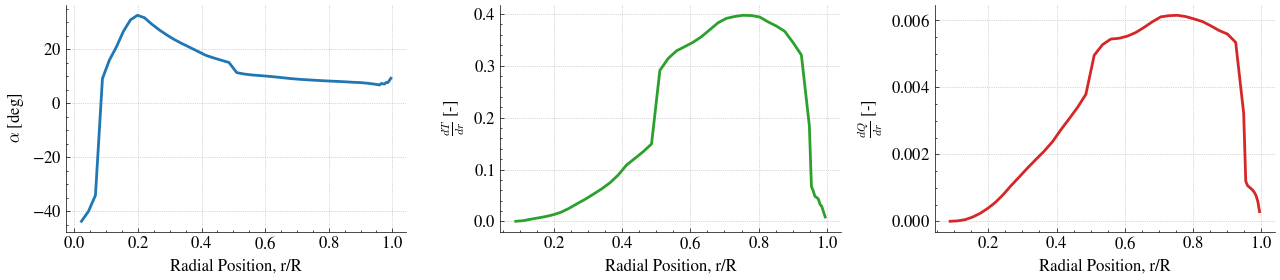

In [4]:
r = sol['r'].to_numpy()
norm_r = r / blade_dict['tip_radius']

fig, axes = plt.subplots(1, 3, figsize=(13, 3))

axes[0].plot(norm_r, sol['alpha'].to_numpy(), linewidth=2, color='tab:blue')
axes[0].set_xlabel('Radial Position, r/R', fontsize=12)
axes[0].set_ylabel('$\\alpha$ [deg]', fontsize=12)
axes[0].grid(True, linestyle=':', alpha=1.0)
axes[0].spines[['top', 'right']].set_visible(False)
axes[0].tick_params(top=False, right=False, which='both', labelsize=12)

axes[1].plot(norm_r, sol['d_t'].to_numpy(), linewidth=2, color='tab:green')
axes[1].set_xlabel('Radial Position, r/R', fontsize=12)
axes[1].set_ylabel('$\\frac{dT}{dr}$ [-]', fontsize=12)
axes[1].grid(True, linestyle=':', alpha=1.0)
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].tick_params(top=False, right=False, which='both', labelsize=12)

axes[2].plot(norm_r, sol['d_q'].to_numpy(), linewidth=2, color='tab:red')
axes[2].set_xlabel('Radial Position, r/R', fontsize=12)
axes[2].set_ylabel('$\\frac{dQ}{dr}$ [-]', fontsize=12)
axes[2].grid(True, linestyle=':', alpha=1.0)
axes[2].spines[['top', 'right']].set_visible(False)
axes[2].tick_params(top=False, right=False, which='both', labelsize=12)

plt.tight_layout()
plt.show()